
## Kiwifruit Quality Grading - Full ML Workflow  
This notebook walks through a complete end‑to‑end machine learning workflow for predicting the quality grade of kiwifruit (A, B, C, or Reject).

## Import Libraries for Data Handling, Visualisation & Machine Learning

In [1]:
# Core data manipulation libraries
import pandas as pd      # For working with tables of data
import numpy as np       # For numerical operations

# Visualisation libraries for charts and plots
import seaborn as sns
import matplotlib.pyplot as plt

# Scikit‑learn tools for splitting data, scaling, training, and evaluating models
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Machine learning models we will test
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# For saving the final trained model to a file
import joblib

# Hide unnecessary warnings to keep the output tidy
import warnings
warnings.filterwarnings("ignore")

# Set a clean visual style for plots
sns.set(style="whitegrid")

## Load the Dataset

In [2]:
# Load the kiwifruit dataset from CSV
df = pd.read_csv("kiwifruit_quality.csv")

## Basic Exploration

In [3]:
# Display the first few rows to understand the structure of the dataset
df.head()

,FruitID,Weight_g,Diameter_mm,Length_mm,DryMatter_pct,Brix,Firmness_kgf,SkinDefects_pct,ShapeIndex,Grade
0,1,102.5,56.3,69.6,15.3,6.8,5.7,5.3,0.81,B
1,2,92.9,56.2,70.9,15.5,6.7,5.5,6.4,0.79,B
2,3,104.7,50.8,69.9,15.6,5.8,5.1,1.7,0.73,B
3,4,117.8,56.7,72.4,16.9,7.0,5.5,1.4,0.78,A
4,5,91.5,60.9,76.2,14.4,5.3,6.0,2.8,0.80,B


In [4]:
# Show data types and whether any values are missing
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   FruitID          5000 non-null   int64  
 1   Weight_g         5000 non-null   float64
 2   Diameter_mm      5000 non-null   float64
 3   Length_mm        5000 non-null   float64
 4   DryMatter_pct    5000 non-null   float64
 5   Brix             5000 non-null   float64
 6   Firmness_kgf     5000 non-null   float64
 7   SkinDefects_pct  5000 non-null   float64
 8   ShapeIndex       5000 non-null   float64
 9   Grade            5000 non-null   str    
dtypes: float64(8), int64(1), str(1)
memory usage: 396.8 KB


In [5]:
# Summary statistics for numerical columns (mean, min, max, etc.)
df.describe()

,FruitID,Weight_g,Diameter_mm,Length_mm,DryMatter_pct,Brix,Firmness_kgf,SkinDefects_pct,ShapeIndex
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,95.137000,57.961400,72.037200,15.523580,6.486400,5.491580,3.023180,0.806502
std,1443.520003,14.799921,4.033221,3.496226,1.501424,0.782857,0.994373,3.036585,0.068901
min,1.000000,60.000000,45.000000,60.200000,10.000000,4.500000,2.500000,0.000000,0.580000
25%,1250.750000,85.100000,55.300000,69.700000,14.500000,5.900000,4.800000,0.900000,0.760000
50%,2500.500000,95.200000,57.900000,72.000000,15.500000,6.500000,5.500000,2.100000,0.800000
75%,3750.250000,105.000000,60.700000,74.400000,16.600000,7.000000,6.200000,4.200000,0.850000
max,5000.000000,150.000000,70.000000,84.000000,20.000000,9.000000,8.000000,27.400000,1.080000


### **Key Insights from the Summary Statistics**

**Fruit Size (Weight, Diameter, Length)**  
- Weight averages around **95 g**, ranging from **60–150 g**.  
- Diameter and length show natural variation.  
- These features help the model learn size‑related grading patterns.

**Internal Quality (Dry Matter %, Brix)**  
- Dry Matter averages **15.5%** (range: 10–20%).  
- Brix averages **6.49**, with a healthy spread.  
- Strong indicators of eating quality.

**Firmness**  
- Firmness averages **5.49 kgf**, ranging from **2.5–8.0 kgf**.  
- Useful for distinguishing softer vs firmer fruit.

**Skin Defects (%)**  
- Average defects: **3.02%**, with values up to **27.4%**.  
- Most variable feature; strongly influences lower grades.

**Shape Index**  
- Average: **0.807**, with low variance.  
- Likely a weaker predictor compared with other features.

## Grade Distribution

In [6]:
# Distribution of the target variable (fruit quality grade) - count how many kiwifruit belong to each grade category
df['Grade'].value_counts()

Grade
B         3148
C         1296
A          321
Reject     235
Name: count, dtype: int64

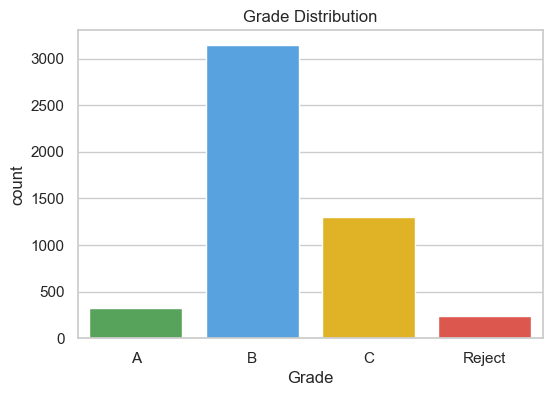

In [7]:
# Visualise the class distribution to check for imbalance
# Plot how many samples belong to each grade
# This helps identify class imbalance (e.g., too many A's, too few Rejects)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Grade", order=["A", "B", "C", "Reject"], palette=["#4CAF50", "#42A5F5", "#FFC107", "#F44336"])
plt.title("Grade Distribution")
plt.show()



### **Grade Distribution Summary**

The grade distribution is noticeably imbalanced. Grade **B** dominates the dataset, making up the majority of samples, followed by Grade **C**. Only a small proportion of fruit achieve **Grade A**, and an even smaller number fall into the **Reject** category. This pattern reflects a realistic packhouse scenario where most fruit meet mid‑tier quality standards, while premium and reject fruit are naturally less common.  

From a machine‑learning perspective, this imbalance means the model may be biased towards predicting the more frequent classes. Techniques such as **stratified sampling**, **class weighting**, or using metrics like **F1‑score** will help ensure fair evaluation across all grades.

## Correlation Heatmap

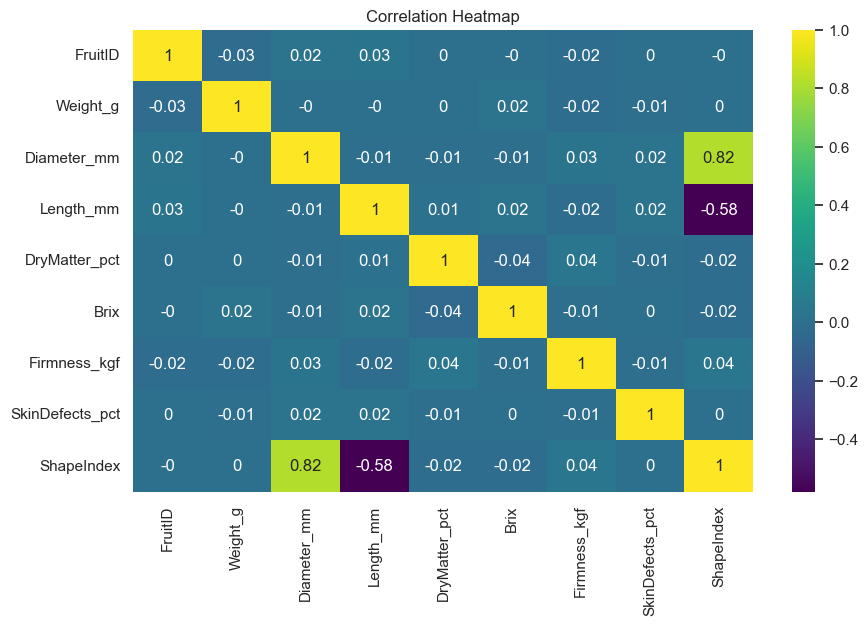

In [8]:
# Plot correlations between numerical features to identify relationships
# Select only numerical columns and plot their correlations
# This helps identify which features move together

plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(include=["number"])
sns.heatmap(numeric_df.corr().round(2), cmap="viridis", annot=True)
plt.title("Correlation Heatmap")
plt.show()

### **Key Insights from Correlation Heatmap**

The correlation heatmap highlights several important relationships between the numeric features in the dataset:

- **Weight, Diameter, and Length** show **strong positive correlations**, confirming that larger fruit tend to be heavier and wider.  
- **ShapeIndex** is strongly correlated with **Weight** and **Diameter**, but negatively correlated with **Length**, indicating that rounder fruit tend to be shorter and heavier.  
- **Dry Matter**, **Brix**, and **Firmness** show **weak correlations** with size‑related features, suggesting that internal quality is largely independent of physical size.  
- **SkinDefects_pct** has **very low correlation** with most features, meaning defects occur independently of size, sweetness, or firmness.  
- Overall, the dataset shows **clear size‑related clusters**, while quality‑related attributes remain mostly uncorrelated, a useful pattern for machine‑learning models, as it reduces redundancy between predictors.

## Feature Preparation

In [9]:
# Remove non‑predictive identifiers and separate features from the target label
# Remove columns that should NOT be used for prediction
# FruitID is just an identifier, and Grade is the target label

X = df.drop(columns =["FruitID", "Grade"])

y = df["Grade"]

## Train / Test Split

In [10]:
# Split the dataset into training and testing sets
# The model learns from the training set and is evaluated on the test set
# Stratification ensures the grade distribution is preserved in both sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Define Models & Hyperparameters

In [11]:
# A dictionary of machine learning models we want to compare

models = {
    "RandomForest": RandomForestClassifier(random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=500),
    "SVM": SVC()
}

### **Why Use Four Models?**
Because each model sees the data differently.  
Using all four gives us a fair, well‑rounded comparison so we can confidently choose the best model for kiwifruit grading.

| Model | Learns  | Best For  |
|-------|---------|-----------|
| **Random Forest** | Many decision paths | General performance, noisy data |
| **Gradient Boosting** | Mistake‑correcting trees | High accuracy, subtle patterns |
| **Logistic Regression** | Straight-line boundaries | Baseline comparison |
| **SVM** | Optimal separating boundary | Complex but clean class separation |

In [12]:
# Hyperparameter grids for each model
# GridSearchCV will test all combinations to find the best settings

param_grids = {
    "RandomForest": {
        "model__n_estimators": [150, 300],
        "model__max_depth": [10, 20, None],
        "model__min_samples_split": [2, 5]
    },
    "GradientBoosting": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [2, 3]
    },
    "LogisticRegression": {
        "model__C": [0.5, 1.0, 2.0]
    },
    "SVM": {
        "model__C": [1, 5],
        "model__kernel": ["rbf", "poly"],
        "model__gamma": ["scale", "auto"]
    }
}

## Train & Tune Models

In [13]:
# Store results for comparing all models later
results = []

# Loop through each model in the dictionary
for name, model in models.items():
    print(f"Training {name}...")

    # A Pipeline is like a processing line:
    # 1. First step: scale the data (StandardScaler)
    # 2. Second step: train the chosen model
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    # GridSearchCV tries every hyperparameter combination using cross‑validation
    grid = GridSearchCV(
        pipe,
        param_grids[name],   # hyperparameters to try for this model
        cv=3,                # 3-fold cross-validation
        scoring="accuracy",  # judge based on accuracy
        n_jobs=-1            # use all CPU cores for speed
    )

    # Train the model using all hyperparameter combinations
    grid.fit(X_train, y_train)

    # Get the best version of the model found by GridSearchCV
    best_model = grid.best_estimator_

    # Use the best model to make predictions on the test set
    y_pred = best_model.predict(X_test)

    # Calculate accuracy on unseen data
    acc = accuracy_score(y_test, y_pred)

    # Save the results for later comparison
    results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "Accuracy": acc
    })

    # Show the performance of these models
    print(f"Best Accuracy: {acc:.4f}")
    print("Best Params:", grid.best_params_)
    print("-" * 50)


Training RandomForest...
Best Accuracy: 0.9830
Best Params: {'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 150}
--------------------------------------------------
Training GradientBoosting...
Best Accuracy: 0.9840
Best Params: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 200}
--------------------------------------------------
Training LogisticRegression...
Best Accuracy: 0.7810
Best Params: {'model__C': 2.0}
--------------------------------------------------
Training SVM...
Best Accuracy: 0.9300
Best Params: {'model__C': 5, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
--------------------------------------------------


## Compare Models

In [14]:
# Convert results into a DataFrame for easy sorting and comparison

results_df = pd.DataFrame(results)

results_df.sort_values("Accuracy", ascending=False)

,Model,Best Params,Accuracy
1,GradientBoosting,"{'model__learning_rate': 0.1, 'model__max_dept...",0.984
0,RandomForest,"{'model__max_depth': 20, 'model__min_samples_s...",0.983
3,SVM,"{'model__C': 5, 'model__gamma': 'scale', 'mode...",0.930
2,LogisticRegression,{'model__C': 2.0},0.781


## Evaluate Best Model

In [15]:
# Identify the model with the highest accuracy

best_model_name = results_df.sort_values("Accuracy", ascending=False).iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: GradientBoosting


In [16]:
# Re-train the best model using its optimal hyperparameters

# Create a new GridSearchCV ONLY for the winning model
# This ensures the final model is trained cleanly with the best settings
best_pipe = GridSearchCV(
    Pipeline([
        ("scaler", StandardScaler()),           # Step 1: scale the data
        ("model", models[best_model_name])]),   # Step 2: use the winning model
        param_grids[best_model_name],           # Use the hyperparameter grid for the winning model
        cv=3,                                   # 3-fold cross-validation
        scoring="accuracy",                     # Evaluate using accuracy
        n_jobs=-1                               # Use all CPU cores for speed
)

# Train the winning model with its best hyperparameters
best_pipe.fit(X_train, y_train)

# Extract the final trained model (best version found by GridSearchCV)
final_model = best_pipe.best_estimator_


In [17]:
# Generate predictions and print a detailed classification report

y_pred = final_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           A       0.90      1.00      0.95        64
           B       0.99      0.98      0.99       630
           C       0.99      0.98      0.98       259
      Reject       1.00      1.00      1.00        47

    accuracy                           0.98      1000
   macro avg       0.97      0.99      0.98      1000
weighted avg       0.98      0.98      0.98      1000



### **Metrics Interpretation:**

- **Precision**  
  Measures how often the model is correct *when it predicts a class*.  
  Example: Precision of 0.90 for class A means that when the model predicts “A‑grade,” it is correct 90% of the time.

- **Recall**  
  Measures how many actual samples of a class the model successfully identifies.  
  A recall of 1.00 for class A means the model found *all* A‑grade fruit in the test set.

- **F1‑Score**  
  The harmonic mean of precision and recall.  
  A balanced measure of both correctness and completeness.

- **Support**  
  The number of samples of each class in the test set.

**Key Insights:**

- The model performs **exceptionally well** across all classes, including the minority class **Reject**, which often poses challenges in classification tasks.
- **Class A** has slightly lower precision, meaning the model occasionally mislabels other grades as A, but recall is perfect.
- The overall accuracy of **98%** indicates strong generalisation to unseen data.
- High precision and recall across all classes suggest the model is reliable and suitable for real‑world kiwifruit grading applications.

 ## Confusion Matrix

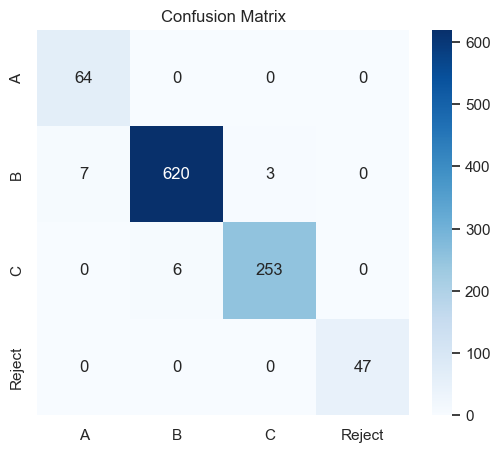

In [18]:
# A confusion matrix shows where the model is making mistakes
# Visualise misclassifications to understand model behaviour

cm = confusion_matrix(y_test, y_pred, labels= ["A", "B", "C", "Reject"])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["A", "B", "C", "Reject"],
    yticklabels=["A", "B", "C", "Reject"]
)
plt.title("Confusion Matrix")
plt.show()

### **The Confusion Matrix**
Counts how many predictions were correct or incorrect for **each class**.

- **y_test** → the *actual* fruit grades  
- **y_pred** → the *model’s predicted* fruit grades  

This creates a **visual grid** where:

- Rows = **actual** classes  
- Columns = **predicted** classes  
- Each cell = number of samples  

Darker blue = more samples  
Lighter blue = fewer samples  

**Confusion Matrix Output Interpretation:**

- Each row shows **what actually happened**.  
- Each column shows **what the model predicted**.
- The **diagonal** (top‑left → bottom‑right) shows **correct predictions**.

Everything **off the diagonal** is a **mistake**.

**Class A (Actual A row)**  
`64  0  0  0`

- 64 A‑grade fruits were predicted correctly  
- 0 were misclassified (perfect performance for A)

**Class B (Actual B row)**  
`7  620  3  0`

Out of 630 B‑grade fruits:

- **620** correctly predicted as B  
- **7** incorrectly predicted as A  
- **3** incorrectly predicted as C  

This is still extremely strong performance.


**Class C (Actual C row)**  
`0  6  253  0`

Out of 259 C‑grade fruits:

- **253** correctly predicted  
- **6** misclassified as B  

Again, very strong.


**Reject (Actual Reject row)**  
`0  0  0  47`

- All 47 Reject fruits were predicted correctly  
- **Perfect performance**

**What This Means Overall**

The model is performing **really well**:

- Almost all predictions fall on the **diagonal** (correct)
- Very few misclassifications  
- Most mistakes happen between **B and C**, which is normal because they are often visually similar  
- No Reject fruit was ever misclassified  
- No A fruit was misclassified  

This aligns with the **98% accuracy** and excellent classification report.

## Feature Importance

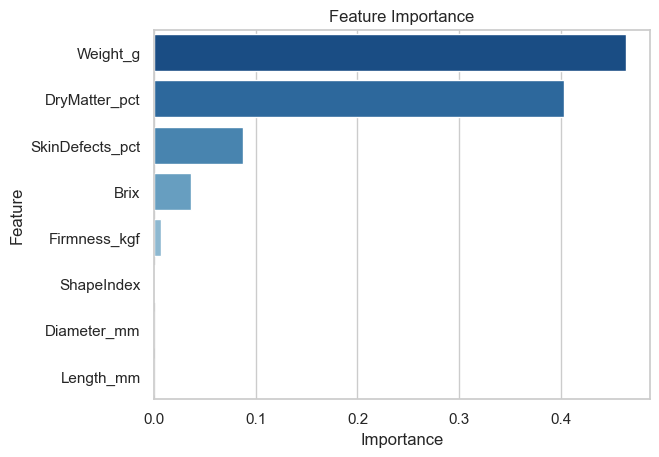

In [19]:
# Some models can show which features were most important for prediction (e.g., Random Forest, Gradient Boosting)

# Check if the final model has a feature_importances_ attribute
# Not all models support this (e.g., Logistic Regression, SVM)
if hasattr(final_model.named_steps["model"], "feature_importances_"):
    
    # Extract the importance values from the model
    importances = final_model.named_steps["model"].feature_importances_
    
    # Create a DataFrame pairing each feature with its importance score
    feat_imp = pd.DataFrame({
        "Feature": X.columns,
        "Importance": importances
    }).sort_values("Importance", ascending=False)  # Sort from most → least important

    # Plot the feature importance as a bar chart
    plt.Figure(figsize=(8, 5))
    sns.barplot(
        data=feat_imp, 
        x="Importance", 
        y="Feature", 
        palette="Blues_r"   # Darker blue = more important
    )
    plt.title("Feature Importance")
    plt.show()

    # Display the DataFrame in the notebook
    feat_imp

else:
    # If the model does not support feature importance, show a message
    print("Feature importance not available for this model")


### **Feature Importance Key Insights**

The feature‑importance plot highlights which input variables contributed most to the model’s predictions.  
This helps explain **how** the model makes decisions and which features it relies on most when grading kiwifruit.

**Based on the chart:**

**1. Weight_g - Most important feature (~0.45)**  
The model relied heavily on **weight** when deciding the grade.  
This means heavier or lighter fruit strongly influences the predicted class.

**2. DryMatter_pct - Very important (~0.40)**  
Dry matter is almost as important as weight.  
This makes sense: dry matter relates to ripeness, sweetness, and internal quality.

**3. SkinDefects_pct - Moderately important**  
The model uses skin defects to help distinguish between higher and lower grades.

**4. Brix, Firmness, ShapeIndex, Diameter, Length - Low importance**  
These features contribute, but only a little.  
The model didn’t rely on them much when making decisions.

**Weight and Dry Matter carry most of the predictive power** for the dataset.

**What This Means**

The model’s decision‑making is driven primarily by **fruit size (weight)** and **internal quality (dry matter)**.  
Surface defects provide additional context, while physical dimensions and firmness contribute minimally.

This insight can guide both:
- **Model refinement** (e.g., focusing on the most predictive features), and  
- **Operational decisions** (e.g., prioritising weight and dry‑matter measurement in grading workflows).

## Save Best Model

In [20]:
# Save the final optimised model for deployment or later use

joblib.dump(final_model, "kiwifruit_grading_ml_model.pkl")
print("kiwifruit_grading_ml_model.pkl file saved")

kiwifruit_grading_ml_model.pkl file saved


## Save Actual & Predicted Grades as CSV File

In [21]:
# Create a DataFrame containing the actual and predicted grades
predictions_df = pd.DataFrame({
    "Actual_Grade": y_test.values,
    "Predicted_Grade": y_pred
})

# Add a column showing whether the prediction was correct (1) or incorrect (0)
predictions_df["Is_Correct"] = (predictions_df["Actual_Grade"] == predictions_df["Predicted_Grade"]).astype(int)

# Save to CSV
predictions_df.to_csv("kiwifruit_grading_ml_predictions.csv", index=False)

print("Predictions saved to kiwifruit_grading_ml_predictions.csv")


Predictions saved to kiwifruit_grading_ml_predictions.csv
